# Data Loading

In [1]:
# import required libraries for data analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [33]:
TrainData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TrainDataV1.csv')
TrainData.columns = TrainData.columns.map(str.lower)
TrainData.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)
# TrainData.drop(['t2m_lag2', 'e_lag2', 'ro_lag2', 'tp_lag2', 'cdir_lag2', 't2m', 'e', 'ro', 'tp', 'cdir'], axis=1, inplace=True)
TrainData.head()

,t2m,e,ro,tp,cdir,month_sin,sin_lat,sin_lon,target
0,-4.307594,1.791817,-0.375822,-0.412930,-1.962209,0.5,0.601815,0.964787,0.0
1,-4.135662,1.766785,-0.375822,-0.514406,-1.972244,0.5,0.601815,0.967046,0.0
2,-4.228733,1.808788,-0.380768,-0.256534,-1.955519,0.5,0.598325,0.961262,0.0
3,-4.364609,1.817274,-0.380768,-0.181610,-1.946093,0.5,0.598325,0.962455,0.0
4,-4.325001,1.817698,-0.380768,-0.220527,-1.935146,0.5,0.598325,0.963630,0.0


In [34]:
import pandas as pd

# 1. Determine the number of samples per class
# We'll take the count of the smallest class to ensure perfect balance
min_class_size = TrainData['target'].value_counts().min()

print(f"Sampling {min_class_size} rows from each of the unique classes.")

# 2. Perform the balanced sampling
TrainData = (
    TrainData.groupby('target', group_keys=False)
    .apply(lambda x: x.sample(n=min_class_size, random_state=42))
)

# 3. Shuffle the final dataframe 
# (groupby/apply keeps classes together, shuffling is better for training)
TrainData = TrainData.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Verify the results
print(TrainData['target'].value_counts())

Sampling 192546 rows from each of the unique classes.
target
0.0    192546
1.0    192546
3.0    192546
2.0    192546
4.0    192546
Name: count, dtype: int64


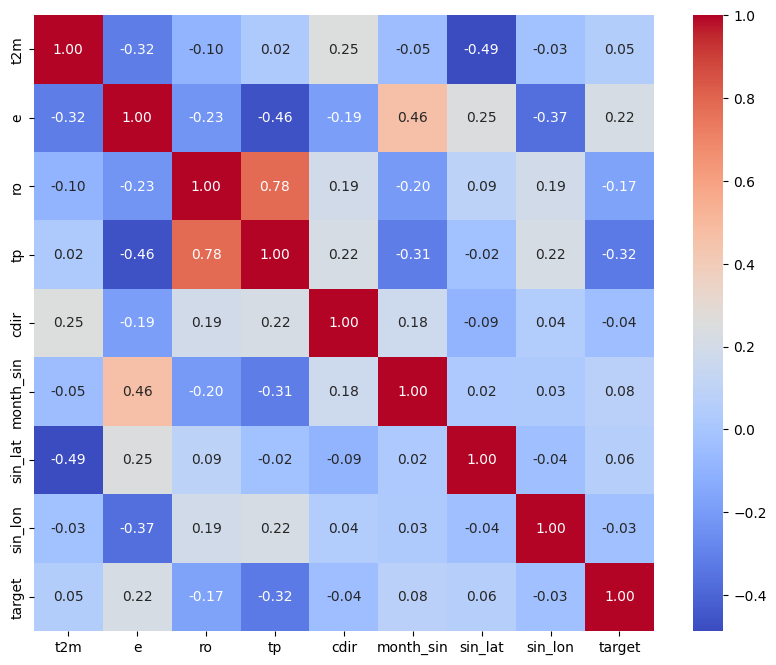

In [35]:
# Set the figure size (width, height) in inches
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(TrainData.corr(), annot=True, cmap='coolwarm', fmt=".2f")

# Show the plot
plt.show()

In [36]:
Xtr, ytr = TrainData.drop('target', axis=1), TrainData['target']

In [38]:
ValidData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ValidDataV1.csv')
ValidData.columns = ValidData.columns.map(str.lower)  
ValidData.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)
# ValidData.drop(['t2m_lag2', 'e_lag2', 'ro_lag2', 'tp_lag2', 'cdir_lag2', 't2m', 'e', 'ro', 'tp', 'cdir'], axis=1, inplace=True)
ValidData.head()

,t2m,e,ro,tp,cdir,month_sin,sin_lat,sin_lon,target
0,-4.179373,1.797502,-0.380768,-0.487673,-2.002652,0.5,0.601815,0.964787,0.0
1,-3.985594,1.719011,-0.380768,-0.548776,-2.002652,0.5,0.601815,0.967046,0.0
2,-4.131239,1.807260,-0.361480,-0.353827,-2.009950,0.5,0.598325,0.961262,0.0
3,-4.273333,1.817867,-0.374091,-0.314910,-1.997483,0.5,0.598325,0.962455,0.0
4,-4.227863,1.816594,-0.380768,-0.342734,-1.984103,0.5,0.598325,0.963630,0.0


In [39]:
Xval, yval = ValidData.drop('target', axis=1), ValidData['target']

In [40]:
TestData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TestDataV1.csv')
TestData.columns = TestData.columns.map(str.lower)    
TestData.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)
# TestData.drop(['t2m_lag1', 'e_lag1', 'ro_lag1', 'tp_lag1', 'cdir_lag1', 't2m', 'e', 'ro', 'tp', 'cdir'], axis=1, inplace=True)
TestData.head()

,t2m,e,ro,tp,cdir,month_sin,sin_lat,sin_lon,target
0,-4.289212,1.813545,-0.380768,-0.518770,-1.951566,0.5,0.601815,0.964787,1.0
1,-4.048542,1.787240,-0.380273,-0.546049,-1.962057,0.5,0.601815,0.967046,0.0
2,-4.257419,1.815666,-0.367909,-0.482035,-1.941075,0.5,0.598325,0.961262,1.0
3,-4.343208,1.819484,-0.376317,-0.441663,-1.934082,0.5,0.598325,0.962455,2.0
4,-4.332551,1.819060,-0.380768,-0.436571,-1.926480,0.5,0.598325,0.963630,2.0


In [41]:
Xte, yte = TestData.drop('target', axis=1), TestData['target']

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score 

In [43]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    # 'SVM': SVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'MLP': MLPClassifier(random_state=42, max_iter=500),
    'KNN': KNeighborsClassifier()
}

In [32]:
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xval)
    y_proba = model.predict_proba(Xval)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(yval, y_pred)
    f1 = f1_score(yval, y_pred, average='macro')
    # roc_auc = roc_auc_score(yval, y_proba, multi_class='ovr', average='macro') if y_proba is not None else 'N/A'
    kappa = cohen_kappa_score(yval, y_pred)
    MCC = matthews_corrcoef(yval, y_pred)
    balanced_acc = balanced_accuracy_score(yval, y_pred)
    
    results[name] = {
        'accuracy': acc,
        'f1_score': f1,
        # 'roc_auc': roc_auc,
        'kappa': kappa,
        'MCC': MCC,
        'balanced_accuracy': balanced_acc
    }
    print(f"{name} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, Kappa: {kappa:.4f}, MCC: {MCC:.4f}, Balanced Accuracy: {balanced_acc:.4f}")

Training Logistic Regression...
Logistic Regression - Accuracy: 0.2839, F1 Score: 0.1526, Kappa: 0.0102, MCC: 0.0124, Balanced Accuracy: 0.1971
Training Random Forest...
Random Forest - Accuracy: 0.4395, F1 Score: 0.2288, Kappa: 0.0488, MCC: 0.0500, Balanced Accuracy: 0.2442
Training XGBoost...
XGBoost - Accuracy: 0.3549, F1 Score: 0.1984, Kappa: 0.0263, MCC: 0.0283, Balanced Accuracy: 0.2272


In [12]:
# Display results in a DataFrame for better visualization
results_df = pd.DataFrame(results).T
print("\nModel Performance Summary:")
print(results_df.sort_values(by='accuracy', ascending=False))   

# save results to csv
results_df.to_csv(r'Results/model_performance_summary_v3.csv', index=True)


Model Performance Summary:
                     accuracy  f1_score     kappa       MCC  balanced_accuracy
Random Forest        0.657891  0.419960  0.389760  0.394514           0.448323
LightGBM             0.575085  0.335415  0.281394  0.289376           0.386808
XGBoost              0.559009  0.334606  0.269606  0.278961           0.392348
CatBoost             0.513334  0.301299  0.232088  0.245056           0.369732
KNN                  0.435857  0.266906  0.156864  0.171405           0.311355
Logistic Regression  0.414055  0.238392  0.139152  0.155802           0.283432
MLP                  0.332659  0.202657  0.097329  0.116246           0.275378


# Hyperparamter Tuning

## For Random Forest using RandomizedSearchCV

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define a targeted, efficient search space
param_distributions = {
    'n_estimators': [100, 200], # Keep trees lower to save time
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt'], # Usually best for classification
    'bootstrap': [True] 
}

# n_iter=10 means total time will be approx (10 iterations * 3 folds * 5 mins) / cores
# If you have 4+ cores, this should finish in roughly 15-30 minutes.
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=10, 
    cv=3, 
    n_jobs=-1, # CRITICAL: This uses all your CPU cores in parallel
    verbose=2,
    scoring='f1_macro'
)

search.fit(Xtr, ytr.ravel())

print(f"Best Score: {search.best_score_}")
print(f"Best Params: {search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_split=2, n_estimators=100; total time= 3.8min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 3.9min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 4.0min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 4.0min
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 4.0min
[CV]

In [11]:
import joblib
import json

# 1. Save the actual model
joblib.dump(search.best_estimator_, r'Results/random_forest_spei_model.pkl')

# 2. Save the best parameters as a JSON file for future reference
with open(r'Results/best_params.json', 'w') as f:
    json.dump(search.best_params_, f)

print("Model and parameters saved successfully.")

Model and parameters saved successfully.


In [13]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, balanced_accuracy_score

# 1. Load the model back into memory
loaded_model = joblib.load(r'Results/random_forest_spei_model.pkl')

# 2. Make predictions on the validation set
# (Ensure X_valid has been normalized using the same Robust/Median method as X_train)
y_valid_pred = loaded_model.predict(Xval)

# 3. Calculate and display performance metrics
print("--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(yval, y_valid_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(yval, y_valid_pred):.4f}")
print(f"F1-Score (Macro): {f1_score(yval, y_valid_pred, average='macro'):.4f}")

# 4. Full Classification Report
print("\nDetailed Classification Report:")
print(classification_report(yval, y_valid_pred))

--- Validation Set Performance ---
Accuracy: 0.6999
Balanced Accuracy: 0.5281
F1-Score (Macro): 0.4868

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.80      0.86    778320
         1.0       0.40      0.56      0.47    195874
         2.0       0.41      0.44      0.42    121735
         3.0       0.36      0.45      0.40     54981
         4.0       0.22      0.39      0.28     18370

    accuracy                           0.70   1169280
   macro avg       0.46      0.53      0.49   1169280
weighted avg       0.75      0.70      0.72   1169280



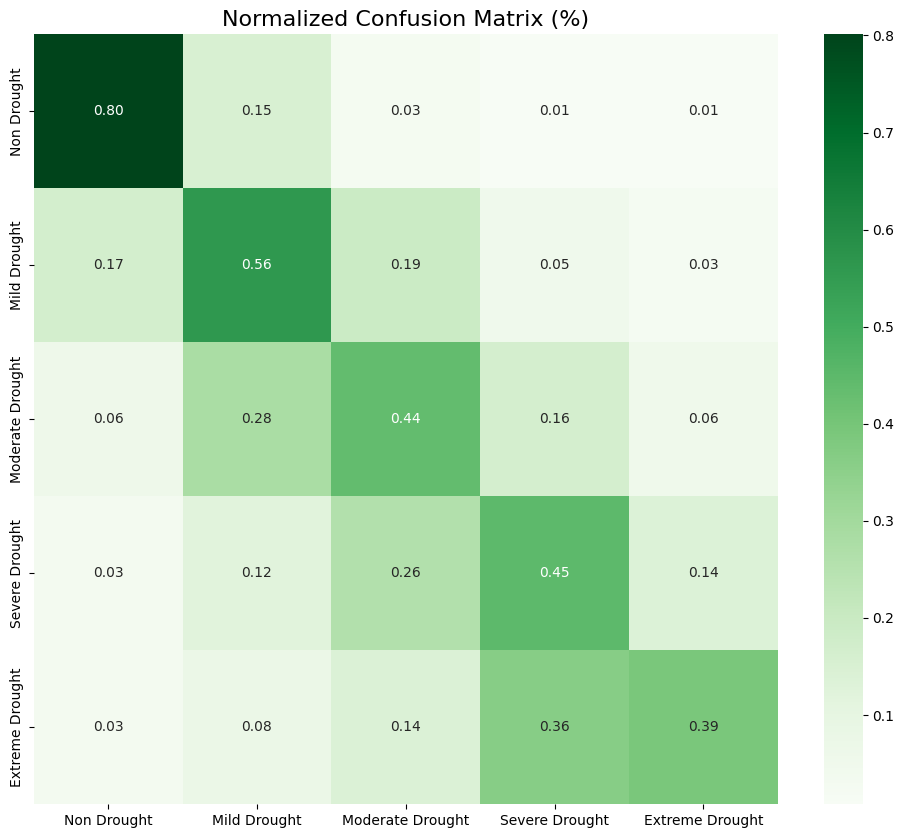

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define your class labels (matching your 9-category logic)
class_names = [
     
    'Non Drought', 'Mild Drought', 'Moderate Drought', 'Severe Drought', 'Extreme Drought'
]

# 2. Generate the confusion matrix
# Replace 'y_test' and 'y_pred' with your actual test labels and model predictions
cm = confusion_matrix(yval, y_valid_pred)

# Compute normalized matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)', fontsize=16)
plt.show()

## CatBoost Hypertuning

In [17]:
from catboost import CatBoostClassifier

# 1. Initialize the model with GPU support
cat_model_gpu = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type='GPU',          # Tells CatBoost to use the GPU
    devices='0',              # Uses the first GPU (index 0)
    random_seed=42,
    verbose=False
)

# 2. Define the parameter grid
# Note: 'depth' on GPU is limited to 16, but 6-10 is best for your data
param_grid = {
    'learning_rate': [0.03, 0.1],
    'depth': [6, 8, 10],
    'l2_leaf_reg': [3, 5, 7],
    'iterations': [1000, 2000],
    'random_strength': [1, 2] # Helps with stability on GPU
}

# 3. Run the search
# With a GPU, you can afford more iterations (n_iter)
random_search_results = cat_model_gpu.randomized_search(
    param_grid,
    X=Xtr,
    y=ytr.ravel(),
    cv=3,
    n_iter=20, 
    # plot=True
)

print("Best parameters:", random_search_results['params'])

bestTest = 0.5720854418
bestIteration = 996
0:	loss: 0.5720854	best: 0.5720854 (0)	total: 15.8s	remaining: 5m
bestTest = 0.5706784001
bestIteration = 999
1:	loss: 0.5706784	best: 0.5720854 (0)	total: 31.3s	remaining: 4m 41s
bestTest = 0.5427563945
bestIteration = 1999
2:	loss: 0.5427564	best: 0.5720854 (0)	total: 1m 2s	remaining: 5m 54s
bestTest = 0.5720854418
bestIteration = 996
3:	loss: 0.5720854	best: 0.5720854 (0)	total: 1m 18s	remaining: 5m 13s
bestTest = 0.6074508008
bestIteration = 1999
4:	loss: 0.6074508	best: 0.6074508 (4)	total: 1m 49s	remaining: 5m 29s
bestTest = 0.5490943651
bestIteration = 996
5:	loss: 0.5490944	best: 0.6074508 (4)	total: 2m 13s	remaining: 5m 10s
bestTest = 0.6138793667
bestIteration = 998
6:	loss: 0.6138794	best: 0.6138794 (6)	total: 2m 36s	remaining: 4m 51s
bestTest = 0.5901996919
bestIteration = 1996
7:	loss: 0.5901997	best: 0.6138794 (6)	total: 3m 23s	remaining: 5m 5s
bestTest = 0.5881477054
bestIteration = 1999
8:	loss: 0.5881477	best: 0.6138794 (6)	t

In [18]:
# Save the model
cat_model_gpu.save_model(r'Results/catboost_spei_model.cbm')

# Load the model
from catboost import CatBoostClassifier
loaded_cat = CatBoostClassifier()
loaded_cat.load_model(r'Results/catboost_spei_model.cbm')

# Predict on validation data
y_valid_pred = loaded_cat.predict(Xval)

# 3. Calculate and display performance metrics
print("--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(yval, y_valid_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(yval, y_valid_pred):.4f}")
print(f"F1-Score (Macro): {f1_score(yval, y_valid_pred, average='macro'):.4f}")

--- Validation Set Performance ---
Accuracy: 0.7088
Balanced Accuracy: 0.5365
F1-Score (Macro): 0.4954


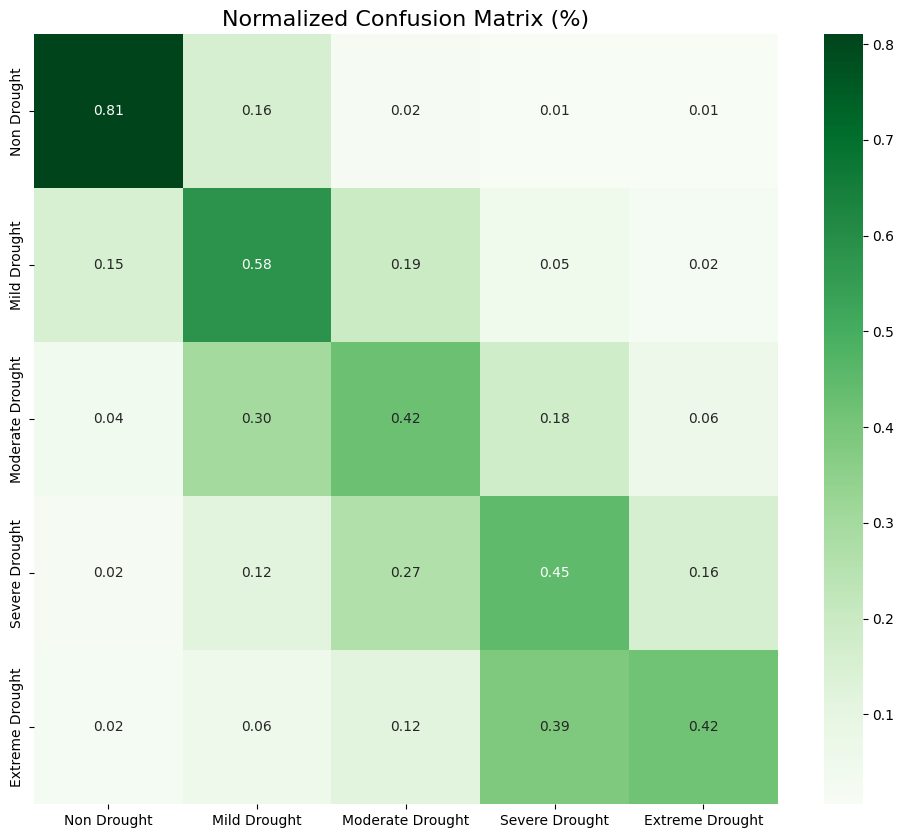

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define your class labels (matching your 9-category logic)
class_names = [
     
    'Non Drought', 'Mild Drought', 'Moderate Drought', 'Severe Drought', 'Extreme Drought'
]

# 2. Generate the confusion matrix
# Replace 'y_test' and 'y_pred' with your actual test labels and model predictions
cm = confusion_matrix(yval, y_valid_pred)

# Compute normalized matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)', fontsize=16)
plt.show()

## XGBoost Hypertuning

In [31]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    # Narrowing down around your 500/0.05 baseline
    'n_estimators': [400, 500, 600],
    'learning_rate': [0.03, 0.05, 0.07],
    
    # Keeping your depth and regularization stable
    'max_depth': [8, 10],
    'min_child_weight': [3, 5],
    'gamma': [0.1, 0.2],
    
    # Fixed parameters from your manual success
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1],
    'reg_lambda': [1.0]
}

# Run the grid search using these centered values
grid_search = GridSearchCV(
    XGBClassifier(tree_method='hist', device='cuda', random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(Xtr, ytr.ravel())

Fitting 3 folds for each of 72 candidates, totalling 216 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'gamma': [0.1, 0.2], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [8, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [32]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}
Best Score: 0.5604781893841803


In [33]:
import joblib
import json

# 1. Save the best model (the booster and its weights)
joblib.dump(grid_search.best_estimator_, r'Results/xgb_spei_best_model.pkl')

# 2. Save the best parameters to a JSON file for documentation
with open(r'Results/xgb_best_params.json', 'w') as f:
    json.dump(grid_search.best_params_, f)

print("XGBoost model and best parameters saved successfully.")

XGBoost model and best parameters saved successfully.


In [34]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the saved model
loaded_xgb = joblib.load(r'Results/xgb_spei_best_model.pkl')

# 2. Perform prediction
# Ensure X_valid has the same preprocessing (RobustScaler/Median-IQR)
y_valid_pred = loaded_xgb.predict(Xval)

# 3. Print Evaluation Metrics
print("--- XGBoost Validation Performance ---")
print(f"Accuracy: {accuracy_score(yval, y_valid_pred):.4f}")
print(f"Macro F1-Score: {f1_score(yval, y_valid_pred, average='macro'):.4f}")

--- XGBoost Validation Performance ---
Accuracy: 0.6538
Macro F1-Score: 0.4106


In [23]:
from xgboost import XGBClassifier

model = XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method='hist',
        device='cuda',
        # eval_metric='mlogloss'
    )
model.fit(Xtr, ytr.ravel())
y_valid_pred = model.predict(Xval)

# 3. Calculate and display performance metrics
print("--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(yval, y_valid_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(yval, y_valid_pred):.4f}")
print(f"F1-Score (Macro): {f1_score(yval, y_valid_pred, average='macro'):.4f}")

--- Validation Set Performance ---
Accuracy: 0.6797
Balanced Accuracy: 0.4900
F1-Score (Macro): 0.4454


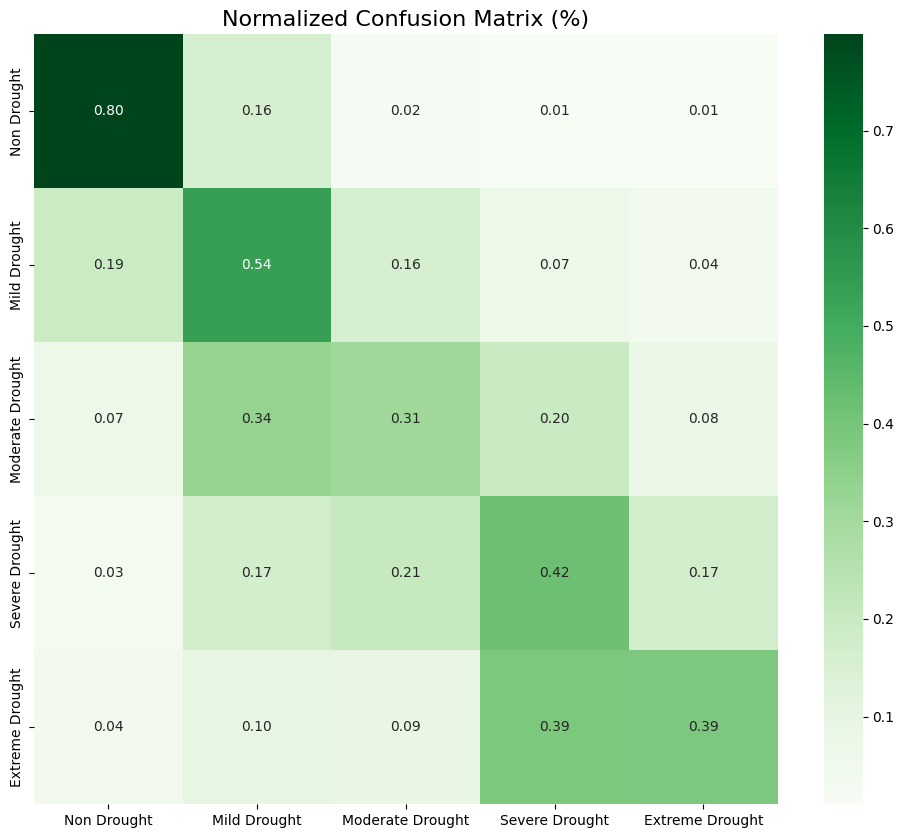

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define your class labels (matching your 9-category logic)
class_names = [
     
    'Non Drought', 'Mild Drought', 'Moderate Drought', 'Severe Drought', 'Extreme Drought'
]

# 2. Generate the confusion matrix
# Replace 'y_test' and 'y_pred' with your actual test labels and model predictions
cm = confusion_matrix(yval, y_valid_pred)

# Compute normalized matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)', fontsize=16)
plt.show()

# Ensemble Prediction

In [20]:
from sklearn.ensemble import VotingClassifier

# Combine your two best models
ensemble = VotingClassifier(
    estimators=[('rf', loaded_model), ('cat', loaded_cat)],
    voting='soft' # Uses probabilities for a more nuanced decision
)
ensemble.fit(Xtr, ytr.ravel())

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('cat', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [21]:
# Predict on validation data
y_valid_pred =ensemble.predict(Xval)

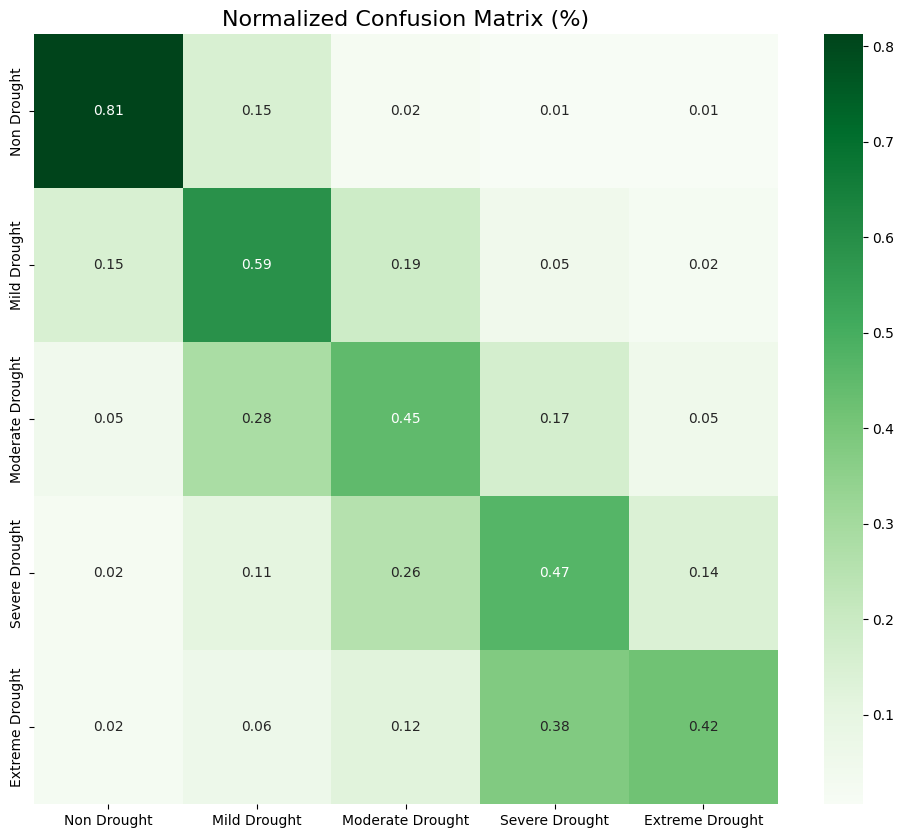

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define your class labels (matching your 9-category logic)
class_names = [
     
    'Non Drought', 'Mild Drought', 'Moderate Drought', 'Severe Drought', 'Extreme Drought'
]

# 2. Generate the confusion matrix
# Replace 'y_test' and 'y_pred' with your actual test labels and model predictions
cm = confusion_matrix(yval, y_valid_pred)

# Compute normalized matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)', fontsize=16)
plt.show()